In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [4]:
import os

print(os.getcwd())

C:\Users\Rishit\Desktop\O2R-Order-prediction\notebooks


In [5]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

In [10]:
RAW_DATA_PATH = "../data/Jan - May '26 Data.csv"

df = pd.read_csv(RAW_DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Shape: (609723, 30)
Rows: 609,723
Columns: 30


In [11]:
print('=== COLUMN NAMES ===')
for col in df.columns:
    print(f'  {col}')

=== COLUMN NAMES ===
  createdAt
  deliveryDate
  orderTime
  orderNumber
  callingAgentId
  callingAgentName
  hubId
  hubName
  customerId
  shopType
  retailerType
  orderSource
  skuNumber
  productType
  itemName
  unitType
  unitWeight
  orderQty
  packedQuantity
  packedTime
  deliveredQty
  deliveredTime
  orderStatus
  skuStatus
  orderToDeliveryTime
  deliveryTimeSlot
  cancellationReason
  brand
  category
  subCategory


In [12]:
print('=== DATA TYPES ===')
print(df.dtypes)

=== DATA TYPES ===
createdAt               object
deliveryDate            object
orderTime               object
orderNumber              int64
callingAgentId          object
callingAgentName        object
hubId                   object
hubName                 object
customerId              object
shopType                object
retailerType            object
orderSource             object
skuNumber               object
productType             object
itemName                object
unitType               float64
unitWeight               int64
orderQty                 int64
packedQuantity           int64
packedTime              object
deliveredQty             int64
deliveredTime           object
orderStatus             object
skuStatus               object
orderToDeliveryTime     object
deliveryTimeSlot        object
cancellationReason      object
brand                   object
category                object
subCategory             object
dtype: object


In [13]:
print('=== FIRST 3 ROWS ===')
df.head(3)

=== FIRST 3 ROWS ===


,createdAt,deliveryDate,orderTime,orderNumber,callingAgentId,callingAgentName,hubId,hubName,customerId,shopType,...,deliveredQty,deliveredTime,orderStatus,skuStatus,orderToDeliveryTime,deliveryTimeSlot,cancellationReason,brand,category,subCategory
0,31-01-2026,02-02-2026,23:55:02,26013101482,NaN,NaN,HB011,Rapid Enterprises,USR-169747,General B,...,1,02-02-2026 16:42,Delivered,DELIVERED,"1 days, 16 hours, 47 minutes",02-02-2026 09:00,NaN,Rajnigandha,Pan Masala,Premium Pan Masala
1,31-01-2026,02-02-2026,23:46:26,26013101481,NaN,NaN,HB011,Rapid Enterprises,USR-169429,Wholesaler,...,0,NaN,CANCELLED,NaN,"1 days, 12 hours, 13 minutes",02-02-2026 12:00,Could not locate shop,Bongchie,Smoking Accessories,Rolling Paper
2,31-01-2026,02-02-2026,23:46:26,26013101481,NaN,NaN,HB011,Rapid Enterprises,USR-169429,Wholesaler,...,0,NaN,CANCELLED,NaN,"1 days, 12 hours, 13 minutes",02-02-2026 12:00,Could not locate shop,Hell Energy Drink,Beverage,Energy Drinks


In [14]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
null_df = null_df[null_df['Null Count'] > 0].sort_values('Null Count', ascending=False)
print('=== COLUMNS WITH NULLS ===')
print(null_df)

=== COLUMNS WITH NULLS ===
                    Null Count  Null %
unitType                609723  100.00
cancellationReason      489714   80.32
callingAgentId          341173   55.96
callingAgentName        341173   55.96
deliveredTime            66593   10.92
skuStatus                66593   10.92
packedTime               16483    2.70
retailerType              2546    0.42
brand                      314    0.05


In [15]:
df['createdAt'] = pd.to_datetime(df['createdAt'], dayfirst=True)
print(f'Date range: {df["createdAt"].min().date()} to {df["createdAt"].max().date()}')
print(f'Total days in dataset: {(df["createdAt"].max() - df["createdAt"].min()).days + 1}')

Date range: 2026-01-01 to 2026-05-31
Total days in dataset: 151


In [16]:
print('=== ORDER STATUS ===')
print(df['orderStatus'].value_counts())
print()
print('=== ORDER SOURCE ===')
print(df['orderSource'].value_counts())
print()
print('=== SHOP TYPE ===')
print(df['shopType'].value_counts())
print()
print('=== RETAILER TYPE ===')
print(df['retailerType'].value_counts())

=== ORDER STATUS ===
orderStatus
Delivered             391923
PartiallyDelivered    151207
CANCELLED              66286
Created                  288
BatchAssigned             14
Dispatched                 5
Name: count, dtype: int64

=== ORDER SOURCE ===
orderSource
App              341161
CALLING_AGENT    268550
SUPER_ADMIN          12
Name: count, dtype: int64

=== SHOP TYPE ===
shopType
Paan B        207785
General A     134777
General B      94164
General C      90649
Paan A         49995
Paan C         25628
Wholesaler      2668
Chemist B       1438
Chemist A       1436
Chemist C       1183
Name: count, dtype: int64

=== RETAILER TYPE ===
retailerType
HVHF    488637
HVLF    114584
LVLF      3717
LVHF       239
Name: count, dtype: int64


In [17]:
print('=== HUB NAME (Top 15) ===')
print(df['hubName'].value_counts().head(15))

=== HUB NAME (Top 15) ===
hubName
Instant Foods(Noida)             134655
Instant Foods (SED)               77274
Rapid Enterprises                 63725
Instant Foods (GZB)               62078
Crossline Events (Meerut)         53796
Crossline Events (Noida)          53597
Cross Line Events (Ghaziabad)     50273
Cross Line Events (EDelhi)        49241
NB Enterprises (West Delhi)       36695
Instant Foods (Mathura)           26602
Maa Sharda(LKO)                    1750
Maa Sharda                           37
Name: count, dtype: int64


In [18]:
print(f'Total SKU-level rows: {len(df):,}')
print(f'Unique order numbers: {df["orderNumber"].nunique():,}')
print(f'Unique retailers (customerId): {df["customerId"].nunique():,}')
print(f'Unique hubs: {df["hubName"].nunique()}')
print(f'Unique shop types: {df["shopType"].nunique()}')

Total SKU-level rows: 609,723
Unique order numbers: 200,201
Unique retailers (customerId): 9,766
Unique hubs: 12
Unique shop types: 10


In [19]:
# Keep only orders that were actually fulfilled
confirmed = df[df['orderStatus'].isin(['Delivered', 'PartiallyDelivered'])]
print(f'Confirmed SKU rows: {len(confirmed):,}')

# Deduplicate to order level
orders = confirmed.drop_duplicates(subset='orderNumber')[['orderNumber','customerId','createdAt','hubName','shopType','retailerType','orderSource']].copy()
print(f'Confirmed unique orders: {len(orders):,}')
print(f'Retailers with at least 1 confirmed order: {orders["customerId"].nunique():,}')

Confirmed SKU rows: 543,130
Confirmed unique orders: 177,340
Retailers with at least 1 confirmed order: 8,640


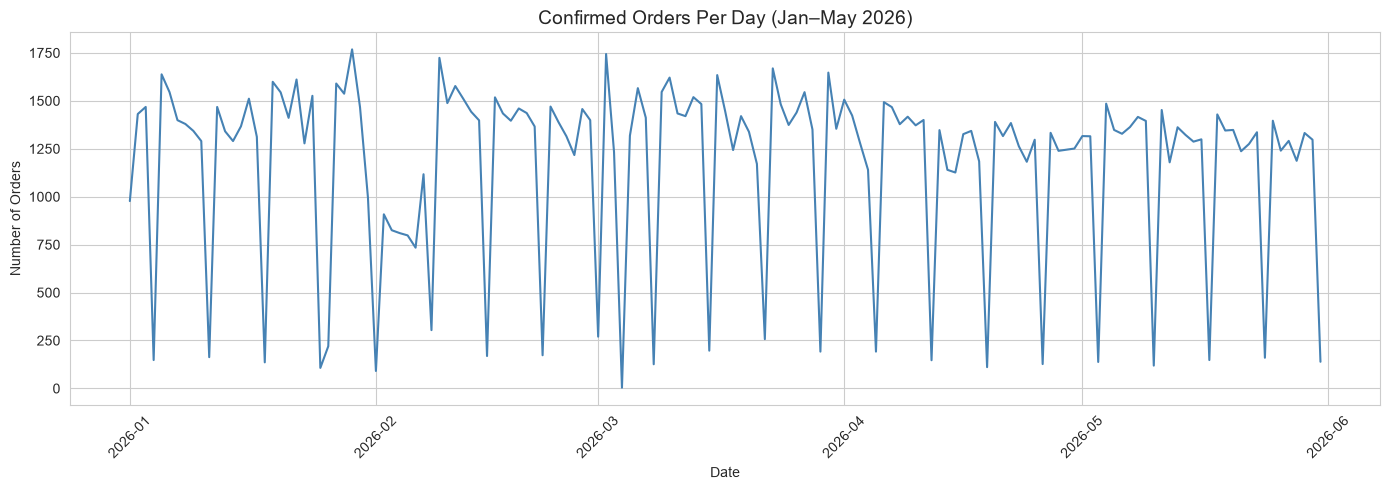

Average orders per day: 1174
Min orders in a day: 4
Max orders in a day: 1768


In [20]:
daily_orders = orders.groupby(orders['createdAt'].dt.date)['orderNumber'].count().reset_index()
daily_orders.columns = ['date', 'order_count']

plt.figure(figsize=(14, 5))
plt.plot(daily_orders['date'], daily_orders['order_count'], color='steelblue', linewidth=1.5)
plt.title('Confirmed Orders Per Day (Jan–May 2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Average orders per day: {daily_orders["order_count"].mean():.0f}')
print(f'Min orders in a day: {daily_orders["order_count"].min()}')
print(f'Max orders in a day: {daily_orders["order_count"].max()}')

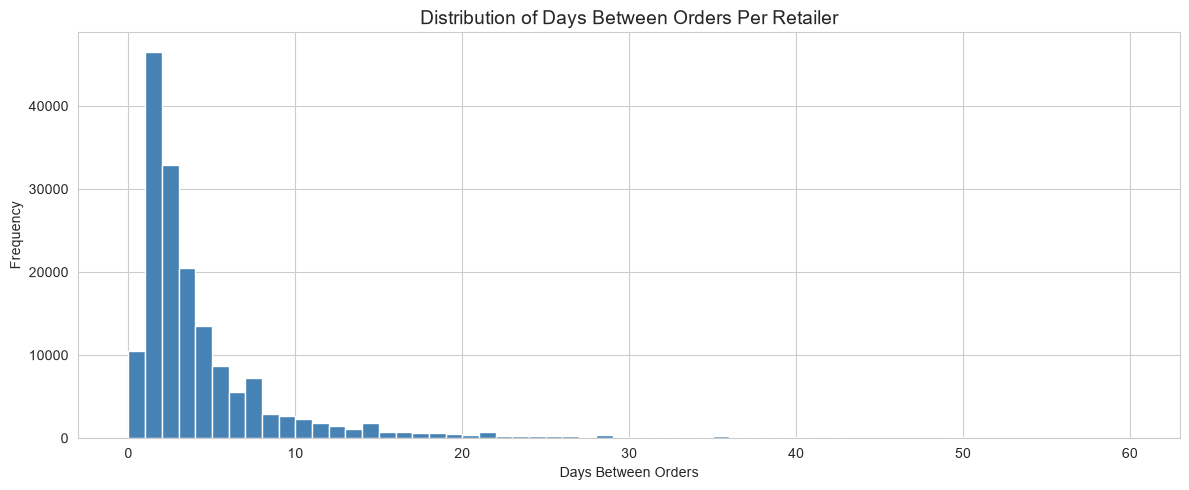

=== GAP STATS (days) ===
count    168700.000000
mean          4.583942
std           7.629959
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max         147.000000
Name: gap_days, dtype: float64


In [21]:
orders_sorted = orders.sort_values(['customerId', 'createdAt'])
orders_sorted['prev_order_date'] = orders_sorted.groupby('customerId')['createdAt'].shift(1)
orders_sorted['gap_days'] = (orders_sorted['createdAt'] - orders_sorted['prev_order_date']).dt.days

gaps = orders_sorted[orders_sorted['gap_days'].notna() & (orders_sorted['gap_days'] <= 60)]

plt.figure(figsize=(12, 5))
plt.hist(gaps['gap_days'], bins=60, color='steelblue', edgecolor='white')
plt.title('Distribution of Days Between Orders Per Retailer', fontsize=14)
plt.xlabel('Days Between Orders')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('=== GAP STATS (days) ===')
print(orders_sorted['gap_days'].describe())

=== ORDERS PER RETAILER (5-month total) ===
count    8640.000000
mean       20.525463
std        24.292309
min         1.000000
25%         3.000000
50%        11.000000
75%        29.000000
max       190.000000
Name: orderNumber, dtype: float64

Retailers with only 1 order (cold start): 1175
Retailers with 2-5 orders: 1904
Retailers with 6+ orders (good for ML): 5561


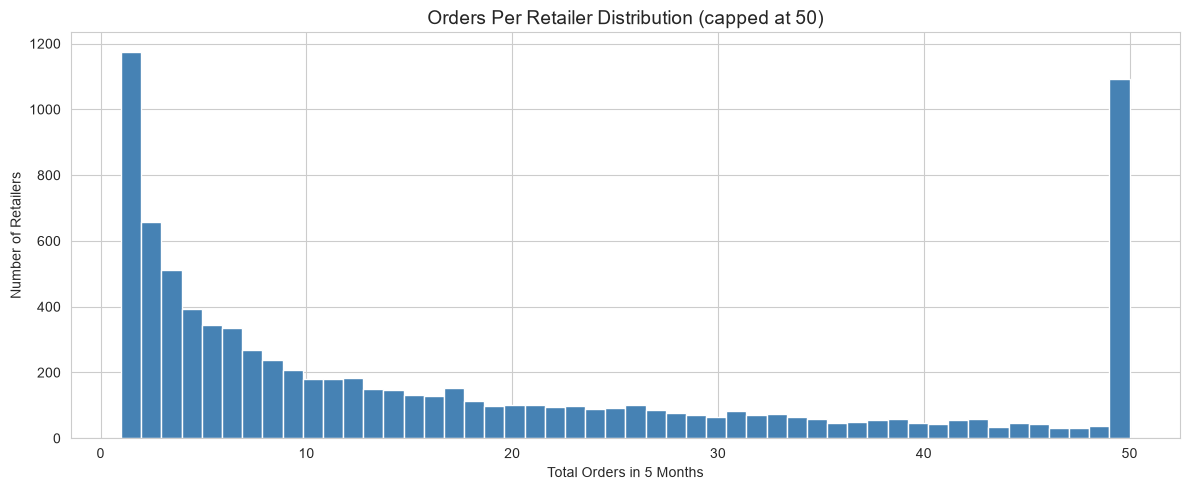

In [22]:
retailer_freq = orders.groupby('customerId')['orderNumber'].count()

print('=== ORDERS PER RETAILER (5-month total) ===')
print(retailer_freq.describe())
print()
print(f'Retailers with only 1 order (cold start): {(retailer_freq == 1).sum()}')
print(f'Retailers with 2-5 orders: {((retailer_freq >= 2) & (retailer_freq <= 5)).sum()}')
print(f'Retailers with 6+ orders (good for ML): {(retailer_freq >= 6).sum()}')

plt.figure(figsize=(12, 5))
retailer_freq.clip(upper=50).hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Orders Per Retailer Distribution (capped at 50)', fontsize=14)
plt.xlabel('Total Orders in 5 Months')
plt.ylabel('Number of Retailers')
plt.tight_layout()
plt.show()

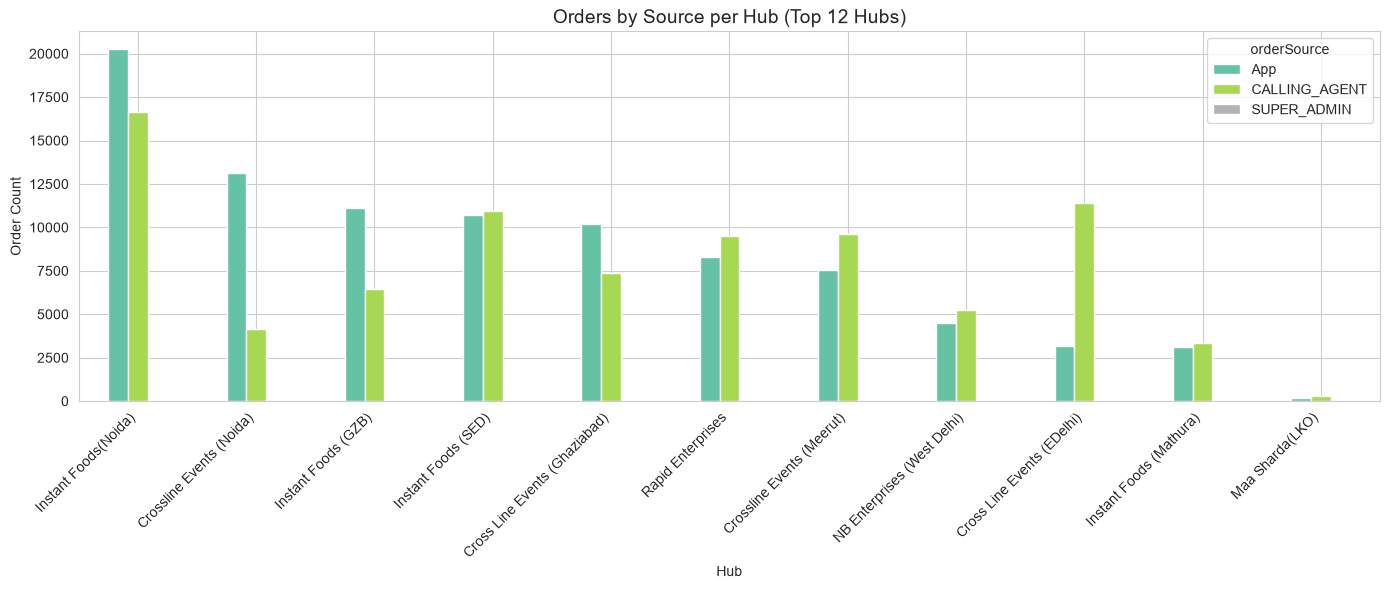

In [23]:
source_hub = orders.groupby(['hubName', 'orderSource'])['orderNumber'].count().unstack(fill_value=0)
source_hub = source_hub.sort_values(source_hub.columns[0], ascending=False).head(12)

source_hub.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title('Orders by Source per Hub (Top 12 Hubs)', fontsize=14)
plt.xlabel('Hub')
plt.ylabel('Order Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
total_retailers = orders['customerId'].nunique()
total_days = (df['createdAt'].max() - df['createdAt'].min()).days + 1
total_retailer_day_rows = total_retailers * total_days
positive_rows = len(orders)  # days when order was placed
negative_rows = total_retailer_day_rows - positive_rows

print(f'Total retailer-day rows (grid size): {total_retailer_day_rows:,}')
print(f'Positive rows (order placed = 1): {positive_rows:,} ({100*positive_rows/total_retailer_day_rows:.1f}%)')
print(f'Negative rows (no order = 0): {negative_rows:,} ({100*negative_rows/total_retailer_day_rows:.1f}%)')
print(f'Class ratio (neg:pos): {negative_rows//positive_rows}:1')
print()
print('This imbalance is handled in Notebook 3 using scale_pos_weight in XGBoost.')

Total retailer-day rows (grid size): 1,304,640
Positive rows (order placed = 1): 177,340 (13.6%)
Negative rows (no order = 0): 1,127,300 (86.4%)
Class ratio (neg:pos): 6:1

This imbalance is handled in Notebook 3 using scale_pos_weight in XGBoost.
